# Cook Zero-Shot Transcription – TrOCR on Cook Line Crops

Zero-shot evaluation of `microsoft/trocr-base-handwritten` on the Cook handwriting dataset.  
No fine-tuning — the model is used as-is from the HuggingFace Hub.

| Split | Source |
|---|---|
| Train | `data/train_set_line_crops/` — alle Seiten außer den 6 Val-Seiten |
| Val | `data/train_set_line_crops/` — B1_P231, B2_P224, B3_P276, B4_P282, B5_P020, B6_P020 |
| Test | `data/test_set_line_crops/` |

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
import numpy as np
import torch
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

ROOT             = Path("..")
TRAIN_CROPS_DIR  = ROOT / "data" / "train_set_line_crops"
TEST_CROPS_DIR   = ROOT / "data" / "test_set_line_crops"

print(f"Random seed : {SEED}")
for p in [TRAIN_CROPS_DIR, TEST_CROPS_DIR]:
    print(f"  {'✓' if p.exists() else '✗'} {p}")

Random seed : 42
  ✓ ../data/train_set_line_crops
  ✓ ../data/test_set_line_crops


## Step 1 – Understand the Dataset

Each page folder contains `*.jpg` (line crop image) and `*.txt` (ground-truth transcription) pairs.

In [2]:
import pandas as pd

def build_dataframe(crops_dir: Path) -> pd.DataFrame:
    records = []
    for page_dir in sorted(crops_dir.iterdir()):
        if not page_dir.is_dir():
            continue
        for img_path in sorted(page_dir.glob("*.jpg")):
            txt_path = img_path.with_suffix(".txt")
            if txt_path.exists():
                transcription = txt_path.read_text(encoding="utf-8").strip()
                records.append({
                    "image_path":    str(img_path),
                    "page":          page_dir.name,
                    "transcription": transcription,
                })
    return pd.DataFrame(records)


df_all_train = build_dataframe(TRAIN_CROPS_DIR)
df_test      = build_dataframe(TEST_CROPS_DIR)

VAL_PAGES = {"B1_P231", "B2_P224", "B3_P276", "B4_P282", "B5_P020", "B6_P020"}

df_train = df_all_train[~df_all_train["page"].isin(VAL_PAGES)].reset_index(drop=True)
df_val   = df_all_train[ df_all_train["page"].isin(VAL_PAGES)].reset_index(drop=True)

print(f"Train pages : {sorted(df_train['page'].unique())}")
print(f"Val pages   : {sorted(df_val['page'].unique())}")
print(f"Test pages  : {sorted(df_test['page'].unique())}")
print()
print(f"Train lines : {len(df_train):>5}")
print(f"Val lines   : {len(df_val):>5}")
print(f"Test lines  : {len(df_test):>5}")

Train pages : ['B1_P057', 'B1_P108', 'B1_P146', 'B1_P151', 'B2_P014', 'B2_P025', 'B2_P052', 'B2_P094', 'B3_P015', 'B3_P069', 'B3_P105', 'B3_P189', 'B4_P019', 'B4_P071', 'B4_P123', 'B4_P171', 'B5_P014', 'B5_P015', 'B5_P016', 'B5_P017', 'B6_P014', 'B6_P015', 'B6_P016', 'B6_P017']
Val pages   : ['B1_P231', 'B2_P224', 'B3_P276', 'B4_P282', 'B5_P020', 'B6_P020']
Test pages  : ['B1_P_206', 'B2_P_260', 'B3_P_162', 'B4_P_178', 'B5_P_279', 'B6_P_060']

Train lines :   726
Val lines   :   194
Test lines  :   189


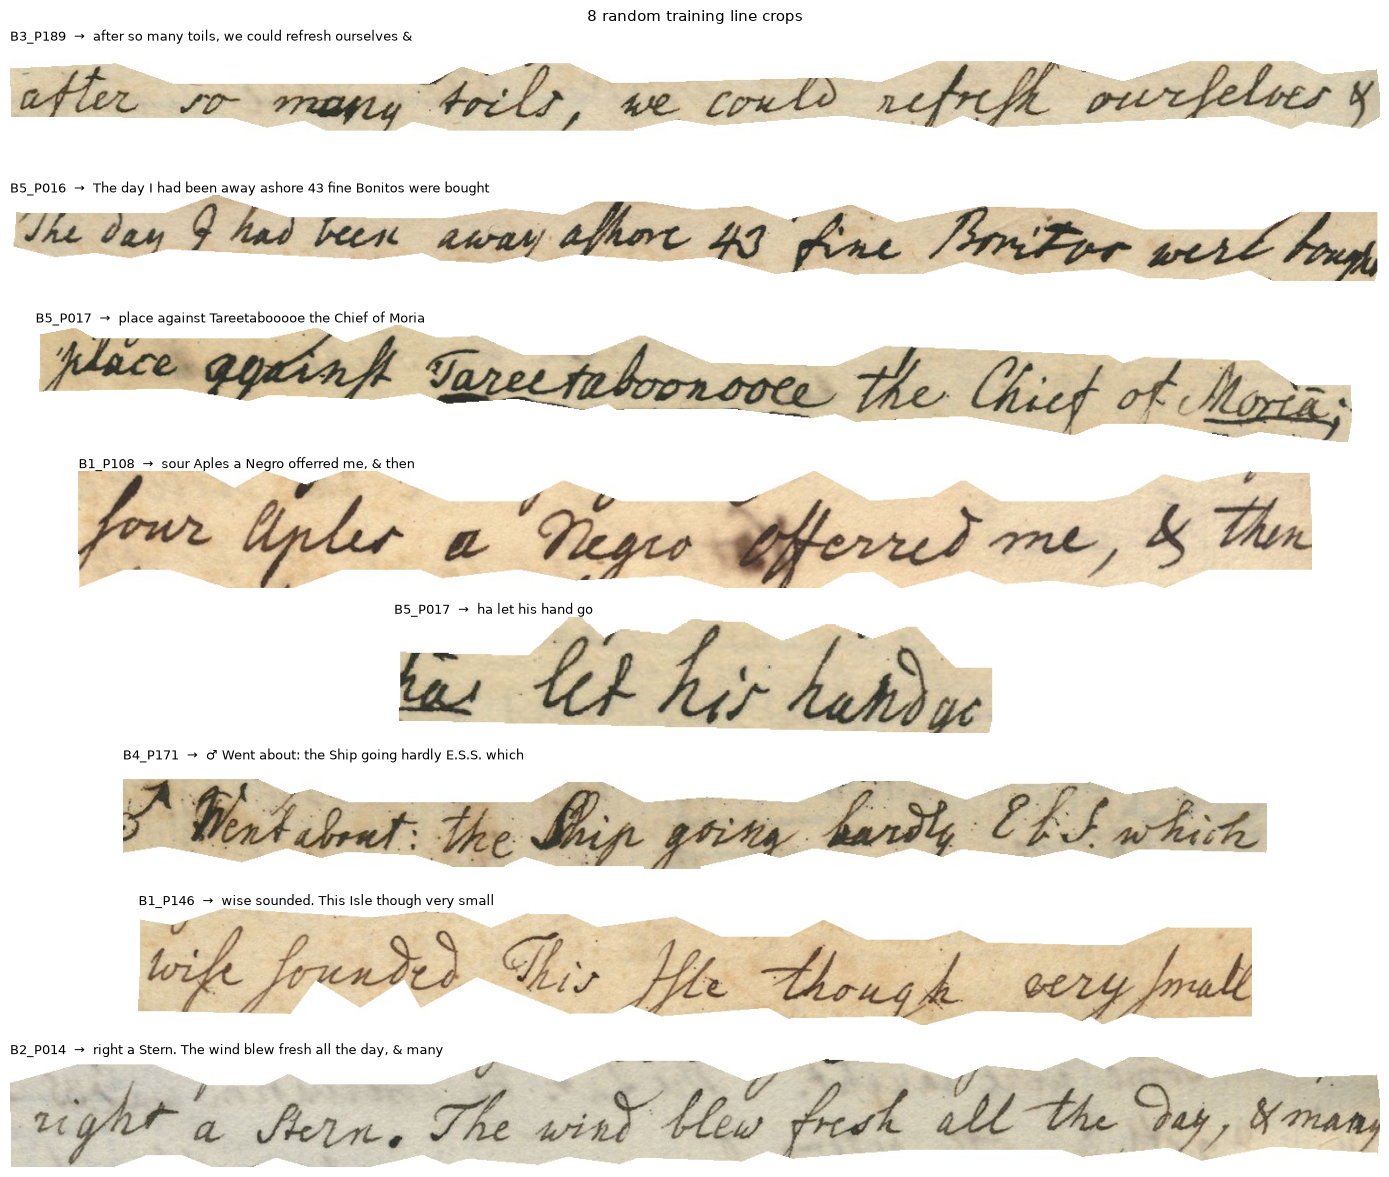

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

sample = df_train.sample(8, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(8, 1, figsize=(14, 12))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"{row['page']}  →  {row['transcription']}",
        fontsize=9, loc="left", pad=2,
    )
    ax.axis("off")
plt.suptitle("8 random training line crops", fontsize=11)
plt.tight_layout()
plt.show()

## Step 2 – Build Dataset Objects

Images are loaded and fed directly to the `TrOCRProcessor`.  
Labels are tokenised for CER/WER computation.

In [4]:
from transformers import TrOCRProcessor

MODEL_NAME = "microsoft/trocr-base-handwritten"
processor  = TrOCRProcessor.from_pretrained(MODEL_NAME)
print(f"Processor loaded from: {MODEL_NAME}")

Processor loaded from: microsoft/trocr-base-handwritten


In [5]:
from torch.utils.data import Dataset, DataLoader


class CookDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df               = df
        self.processor        = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        pixel_values = self.processor(
            images=img, return_tensors="pt"
        ).pixel_values.squeeze(0)

        labels = self.processor.tokenizer(
            row["transcription"],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}


train_dataset = CookDataset(df_train, processor)
val_dataset   = CookDataset(df_val,   processor)
test_dataset  = CookDataset(df_test,  processor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

sample = train_dataset[0]
print(f"pixel_values : {sample['pixel_values'].shape}")
print(f"labels       : {sample['labels'].shape}")
print("DataLoaders OK.")

pixel_values : torch.Size([3, 384, 384])
labels       : torch.Size([128])
DataLoaders OK.


## Step 3 – Zero-Shot Inference

`microsoft/trocr-base-handwritten` is loaded as-is — **no fine-tuning**.  
This is the baseline that subsequent fine-tuned models are compared against.

In [6]:
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.to(device)
model.eval()
print(f"Model loaded (zero-shot): {MODEL_NAME}")

Device: cuda


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded (zero-shot): microsoft/trocr-base-handwritten


In [7]:
import evaluate
from tqdm.notebook import tqdm

cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")


def run_inference(dataloader):
    """Run zero-shot inference; return (predictions, references)."""
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inferring", leave=False):
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs  = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    return all_preds, all_refs


def compute_metrics(preds, refs):
    cer = cer_metric.compute(predictions=preds, references=refs)
    wer = wer_metric.compute(predictions=preds, references=refs)
    return cer, wer


print("Helper functions defined.")

Helper functions defined.


## Step 4 – Evaluation

CER and WER are reported for train, validation and test splits.

In [8]:
print("Running inference on all splits (zero-shot) …")

train_preds, train_refs = run_inference(train_loader)
val_preds,   val_refs   = run_inference(val_loader)
test_preds,  test_refs  = run_inference(test_loader)

train_cer, train_wer = compute_metrics(train_preds, train_refs)
val_cer,   val_wer   = compute_metrics(val_preds,   val_refs)
test_cer,  test_wer  = compute_metrics(test_preds,  test_refs)

results = pd.DataFrame([
    {"Split": "Train", "CER": train_cer, "WER": train_wer, "Lines": len(train_refs)},
    {"Split": "Val",   "CER": val_cer,   "WER": val_wer,   "Lines": len(val_refs)},
    {"Split": "Test",  "CER": test_cer,  "WER": test_wer,  "Lines": len(test_refs)},
])
results[["CER", "WER"]] = results[["CER", "WER"]].applymap(lambda x: round(x, 4))
print(results.to_string(index=False))

Running inference on all splits (zero-shot) …


Inferring:   0%|          | 0/46 [00:00<?, ?it/s]

Inferring:   0%|          | 0/13 [00:00<?, ?it/s]

Inferring:   0%|          | 0/12 [00:00<?, ?it/s]

Split    CER    WER  Lines
Train 0.2847 0.6192    726
  Val 0.2671 0.5739    194
 Test 0.2849 0.5933    189


/tmp/ipykernel_12208/2449243915.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results[["CER", "WER"]] = results[["CER", "WER"]].applymap(lambda x: round(x, 4))


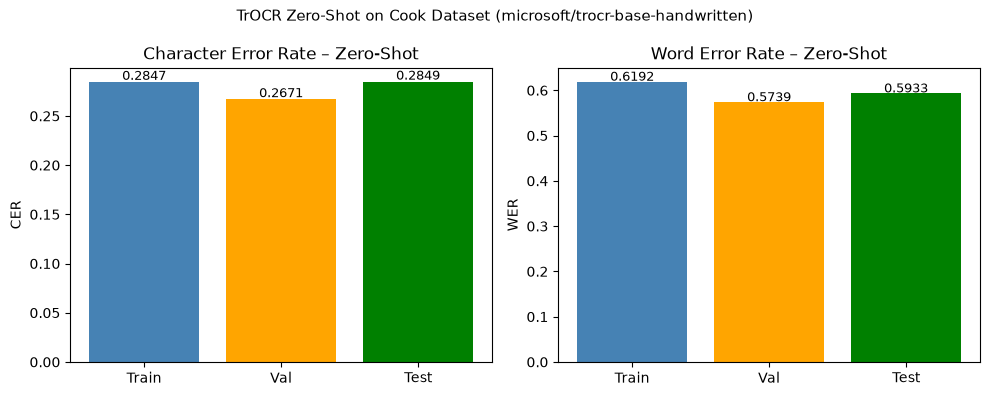

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

splits = results["Split"]
x      = range(len(splits))

axes[0].bar(x, results["CER"], color=["steelblue", "orange", "green"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_ylabel("CER")
axes[0].set_title("Character Error Rate – Zero-Shot")
for i, v in enumerate(results["CER"]):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

axes[1].bar(x, results["WER"], color=["steelblue", "orange", "green"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].set_ylabel("WER")
axes[1].set_title("Word Error Rate – Zero-Shot")
for i, v in enumerate(results["WER"]):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("TrOCR Zero-Shot on Cook Dataset (microsoft/trocr-base-handwritten)", fontsize=11)
plt.tight_layout()
plt.show()

## Step 5 – Qualitative Examples (Test Set)

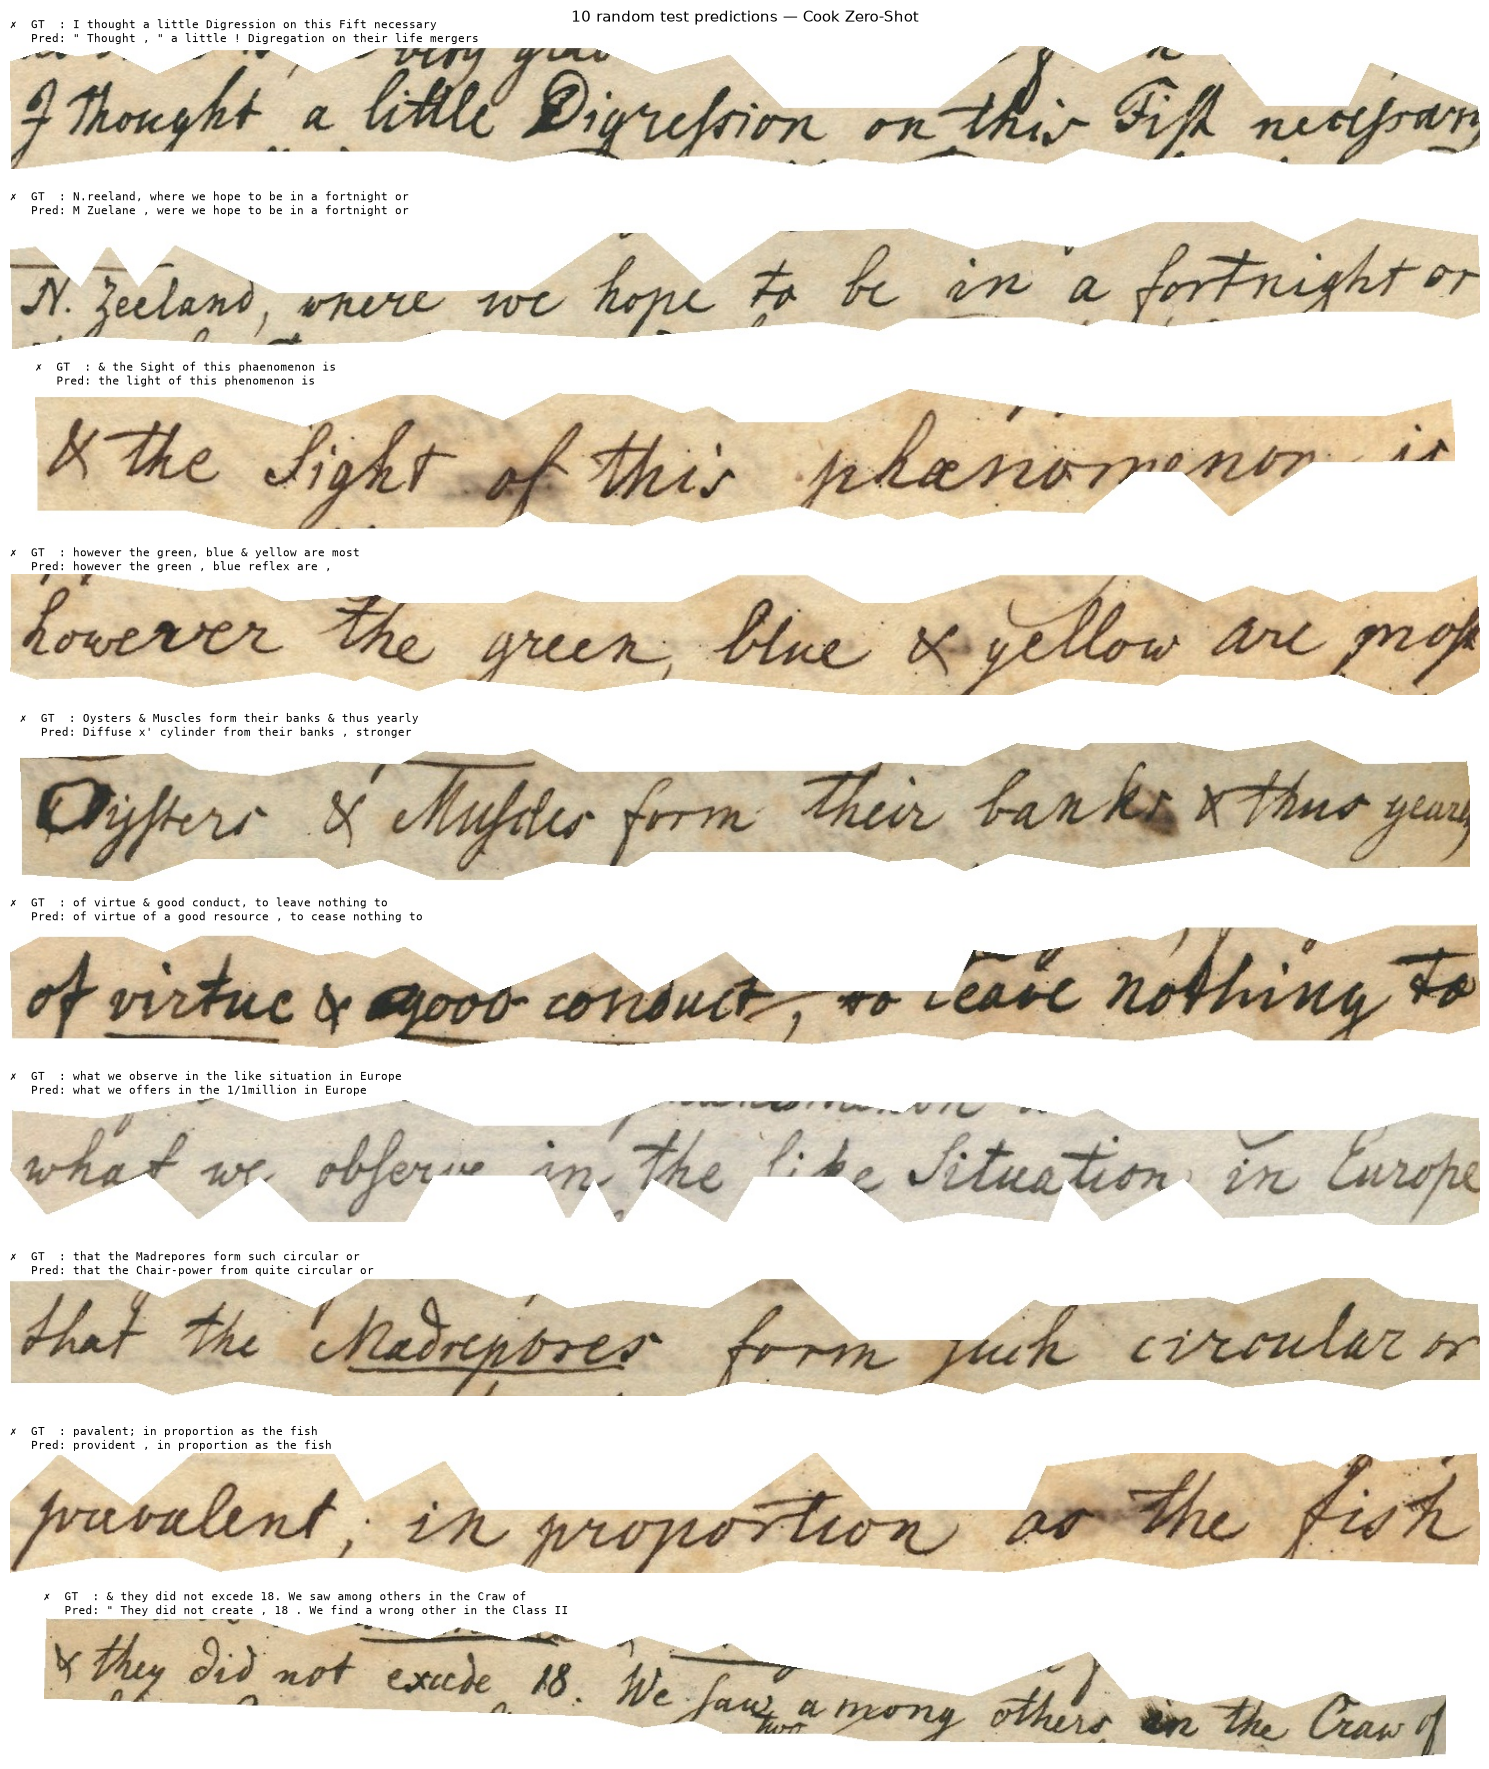

In [10]:
sample_idx = df_test.sample(10, random_state=SEED).index.tolist()

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, idx in zip(axes, sample_idx):
    row   = df_test.iloc[idx]
    img   = Image.open(row["image_path"]).convert("RGB")
    pred  = test_preds[idx]
    ref   = test_refs[idx]
    match = "✓" if pred.strip() == ref.strip() else "✗"
    ax.imshow(img)
    ax.set_title(
        f"{match}  GT  : {ref}\n   Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")
plt.suptitle("10 random test predictions — Cook Zero-Shot", fontsize=11)
plt.tight_layout()
plt.show()

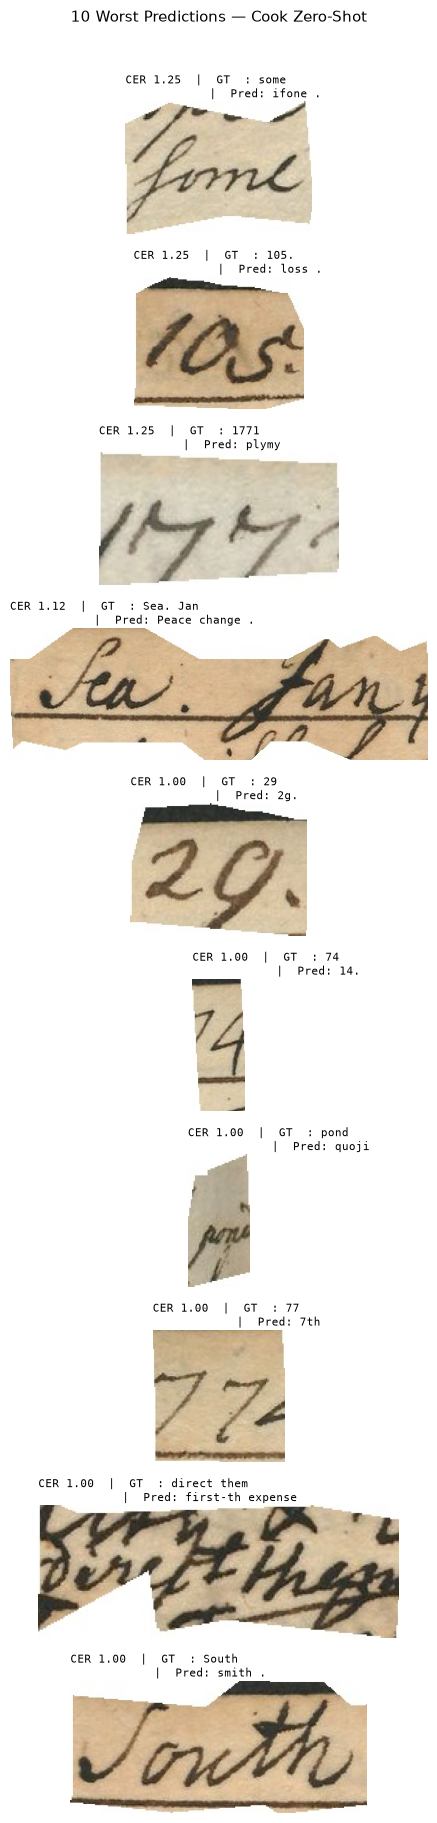

In [11]:
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(test_preds, test_refs)) if ref.strip()],
    reverse=True,
)
worst = errors[:10]

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, (c, idx, ref, pred) in zip(axes, worst):
    row = df_test.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"CER {c:.2f}  |  GT  : {ref}\n"
        f"            |  Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — Cook Zero-Shot", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## Summary

| Split | Lines | CER | WER |
|---|---|---|---|
| Train | — | see above | see above |
| Val   | — | see above | see above |
| Test  | — | see above | see above |

These zero-shot numbers serve as the **baseline** for fine-tuned Cook models.